<a href="https://colab.research.google.com/github/specM7/DSGP_Group_33_Brain_Tumor_Predictor/blob/NoTumor-%26-Chatbot-Ahshaan-2506751/MRI_Validation_CNN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# TensorFlow for deep learning
import tensorflow as tf

# Image preprocessing
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Layers for CNN
from tensorflow.keras import layers, models

# Plot graphs
import matplotlib.pyplot as plt

# Utility libraries
import numpy as np
import os

In [2]:
# Mount Google Drive to access dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Dataset location in Google Drive
data_dir = "/content/drive/MyDrive/Validate_MRI_Image/MRIDataset"

In [4]:
# Image size for CNN input
IMG_SIZE = 224

# Batch size
BATCH_SIZE = 32

# Rescale images and split dataset
datagen = ImageDataGenerator(
    rescale=1./255,        # Normalize pixel values
    validation_split=0.2   # 80% training / 20% validation
)

# Training dataset
train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

# Validation dataset
val_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

# Print class labels
print("Class Labels:", train_generator.class_indices)

Found 9547 images belonging to 2 classes.
Found 2386 images belonging to 2 classes.
Class Labels: {'MRI': 0, 'NonMRI': 1}


In [5]:
# CNN architecture
model = models.Sequential([

    # First convolution layer
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    # Second convolution layer
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Third convolution layer
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Flatten feature maps
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation='relu'),

    # Prevent overfitting
    layers.Dropout(0.5),

    # Output layer (binary classification)
    layers.Dense(1, activation='sigmoid')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Show model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train the CNN model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
 55/299 ━━━━━━━━━━━━━━━━━━━━ 46:53 12s/step - accuracy: 0.8566 - loss: 0.4369

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


299/299 ━━━━━━━━━━━━━━━━━━━━ 3584s 12s/step - accuracy: 0.9504 - loss: 0.1545 - val_accuracy: 0.9992 - val_loss: 0.0022
Epoch 2/15
299/299 ━━━━━━━━━━━━━━━━━━━━ 1331s 4s/step - accuracy: 0.9969 - loss: 0.0093 - val_accuracy: 0.9996 - val_loss: 5.3260e-04
Epoch 3/15
299/299 ━━━━━━━━━━━━━━━━━━━━ 1332s 4s/step - accuracy: 0.9999 - loss: 9.4814e-04 - val_accuracy: 0.9996 - val_loss: 5.8152e-04
Epoch 4/15
299/299 ━━━━━━━━━━━━━━━━━━━━ 1321s 4s/step - accuracy: 0.9992 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 2.5668e-05
Epoch 5/15
299/299 ━━━━━━━━━━━━━━━━━━━━ 1346s 5s/step - accuracy: 0.9996 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 3.1584e-04
Epoch 6/15
299/299 ━━━━━━━━━━━━━━━━━━━━ 1317s 4s/step - accuracy: 0.9972 - loss: 0.0163 - val_accuracy: 1.0000 - val_loss: 9.4190e-05
Epoch 7/15
299/299 ━━━━━━━━━━━━━━━━━━━━ 1327s 4s/step - accuracy: 0.9995 - loss: 0.0024 - val_accuracy: 1.0000 - val_loss: 3.9459e-04
Epoch 8/15
299/299 ━━━━━━━━━━━━━━━━━━━━ 1324s 4s/step - accuracy: 0.9983

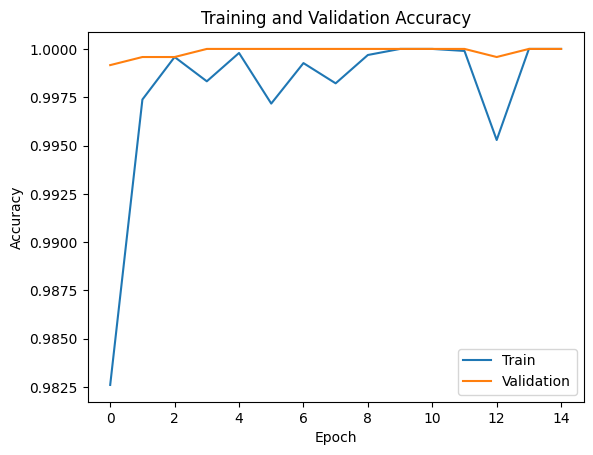

In [7]:
plt.figure()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

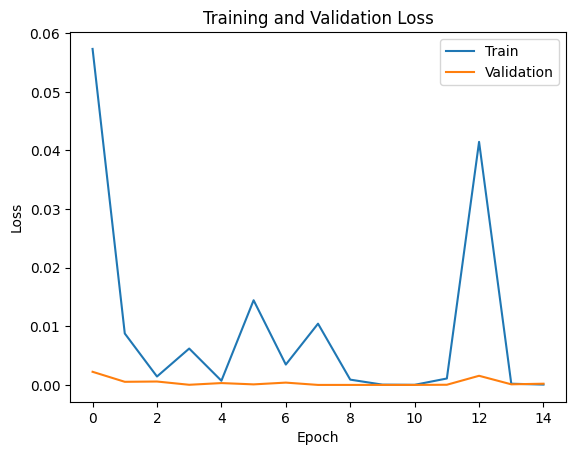

In [8]:
plt.figure()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [9]:
# Save trained model to Google Drive
model.save("/content/drive/MyDrive/Validate_MRI_Image/MRI_Validation_CNN_Model.h5")

print("Model saved successfully.")

Model saved successfully.


In [13]:
# ==============================
# MRI / NON-MRI IMAGE DETECTION
# ==============================

# Import libraries
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
from google.colab import drive, files

# Mount Google Drive
drive.mount('/content/drive')

# Load saved model
model_path = "/content/drive/MyDrive/Validate_MRI_Image/MRI_Validation_CNN_Model.h5"
model = tf.keras.models.load_model(model_path)

print("Model loaded successfully")

# Upload image
uploaded = files.upload()

# Get uploaded file name
img_path = list(uploaded.keys())[0]
print("Uploaded Image:", img_path)

# Load and preprocess image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Expand dimensions
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
prediction = model.predict(img_array)[0][0]

print("Prediction Score:", prediction)

# Final result
if prediction >= 0.5:
    print("Result: Non MRI Image")
else:
    print("Result: MRI Image")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Model loaded successfully


Saving Screenshot 2026-03-05 at 05.30.22.png to Screenshot 2026-03-05 at 05.30.22.png
Uploaded Image: Screenshot 2026-03-05 at 05.30.22.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
Prediction Score: 1.2094875e-23
Result: MRI Image
